# Defect Thermodynamics with Quantum Espresso output

Here, we calculate the carrier concentrations using doped similar to the workflow in GGA_workflow_tutorial.ipynb with data from quantum espresso.

In [1]:
from doped.thermodynamics import get_fermi_dos_from_espresso_dos, scissor_dos

MgO_dos = get_fermi_dos_from_espresso_dos(
    "../tests/data/espresso/MgO_qe/DOS/MgO_bulk_fine_tetrahedra.dos",
    bulk_pwxml="../tests/data/espresso/MgO_qe/Defects/MgO_bulk/espresso_std/espresso.xml",
)


/Users/atharvaanturkar/PycharmProjects/doped_QE/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pymatgen.io.vasp import VolumetricData
from doped.analysis import DefectsParser
%matplotlib inline

In [3]:
bulk_path = "../tests/data/espresso/MgO_qe/Defects/MgO_bulk"
dielectric = 8.8963

In [4]:
calc_root = "../tests/data/espresso/MgO_qe/Defects"
pp_folder = "../tests/data/espresso/pp_folder"

# eFNV corrections use the Gaussian broadening beta (in bohr for espresso .cube); beta = 0.5 (the default)
# is optimal for these cubes - see QE_eFNV_Beta_Tests.ipynb
dp = DefectsParser(code = 'espresso',
                   output_path = calc_root,
                   dielectric=8.8963,
                   beta = 0.5,
                   pp_folder = pp_folder, bulk_path = bulk_path, processes = 1)


Parsing Mg_O_+1/espresso_std: 100%|██████████| 4/4 [00:50<00:00, 12.66s/it]
[PARSED_WITH_WARNING] Folder: Mg_O_+3 | Warning: Projected magnetisation not implemented for QE. Returning None.

[PARSED_WITH_WARNING] Folder: Mg_O_+4 | Warning: Projected magnetisation not implemented for QE. Returning None.

[PARSED_WITH_WARNING] Folder: Mg_O_+2 | Warning: Projected magnetisation not implemented for QE. Returning None.

[PARSED_WITH_WARNING] Folder: Mg_O_+1 | Warning: Projected magnetisation not implemented for QE. Returning None.



In [5]:
from doped.chemical_potentials import CompetingPhasesAnalyzerQE
cpa_QE = CompetingPhasesAnalyzerQE(composition="MgO", entries="/Users/atharvaanturkar/PycharmProjects/doped_QE/tests/data/espresso/MgO_qe/Competing_phases_worked_examples")

Parsing QE `.xml` outputs...:   0%|          | 0/5 [00:00<?, ?it/s]An infinite band gap and CBM were parsed for the calculation in /Users/atharvaanturkar/PycharmProjects/doped_QE/tests/data/QE/MgO_qe/Competing_phases_worked_examples/MgO_Fm-3m_EaH_0/espresso_std/espresso.xml, which indicates that no empty bands were calculated (QE's default `nbnd` with `occupations = 'fixed'` is `nelec/2`) and can cause downstream failures, so these are set to `None`. Add extra bands using the `nbnd` parameter for QE if the band gap of this calculation is needed.

Parsing QE `.xml` outputs...: 100%|██████████| 5/5 [00:00<00:00, 235.52it/s]


In [6]:
MgO_chempots_QE = cpa_QE.chempots

In [7]:
MgO_thermo_QE = dp.get_defect_thermodynamics(
    chempots=MgO_chempots_QE, band_gap=4.8099, bulk_dos = MgO_dos
)

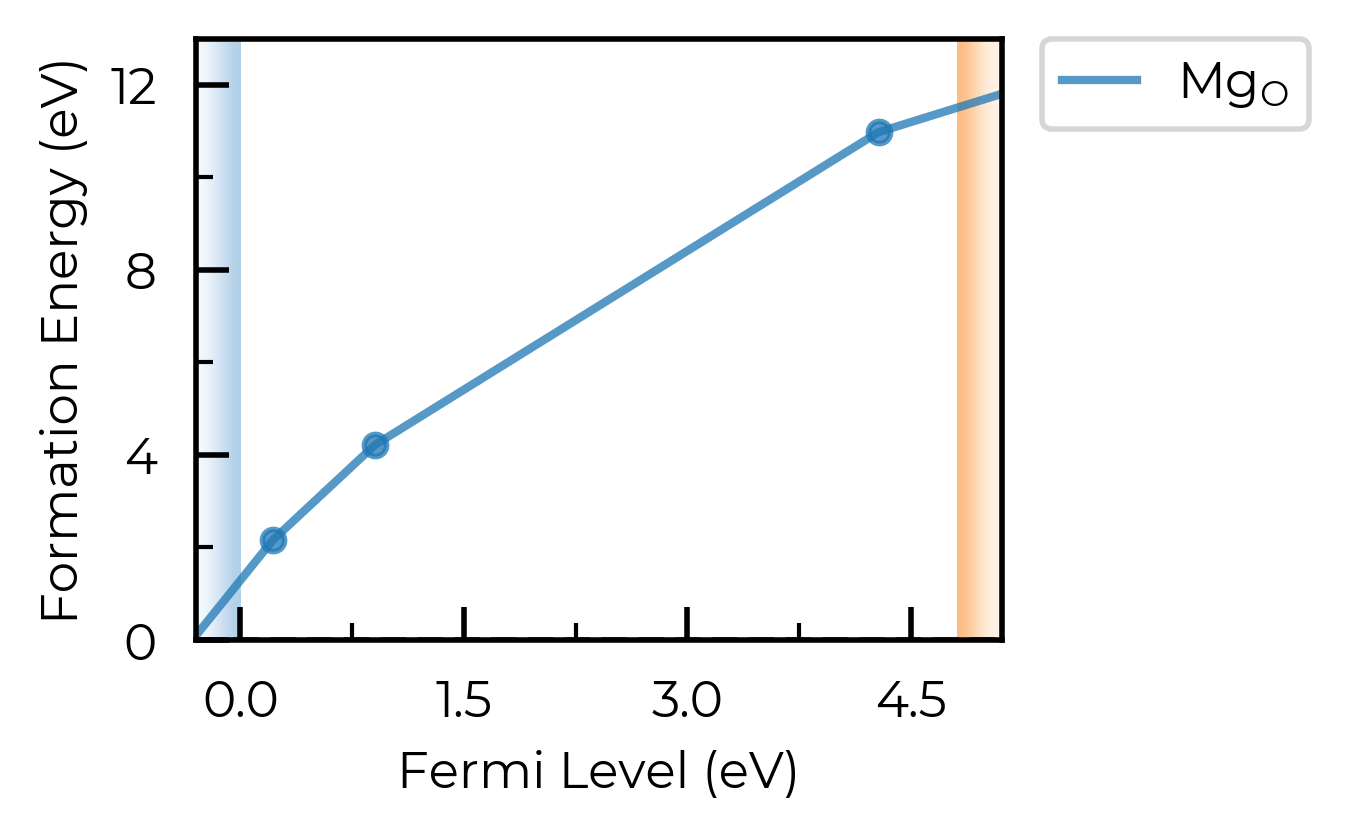

In [8]:
fig = MgO_thermo_QE.plot(limit="MgO-Mg", chempot_table=False)

In [9]:
cpa_QE.chempots_df

,Mg,O
Limit,,
MgO-Mg,0.00000,-5.38616
MgO-O2,-5.38616,0.00000


In [10]:
MgO_thermo_QE.get_symmetries_and_degeneracies()

Site_Symm Defect_Symm  g_Orient  g_Spin  g_Total  Mult
Defect q                                                        
Mg_O   +4        Oh         C2v      12.0     1.0     12.0   1.0
       +3        Oh         C3v       8.0     2.0     16.0   1.0
       +2        Oh         C3v       8.0     1.0      8.0   1.0
       +1        Oh          Cs      24.0     2.0     48.0   1.0

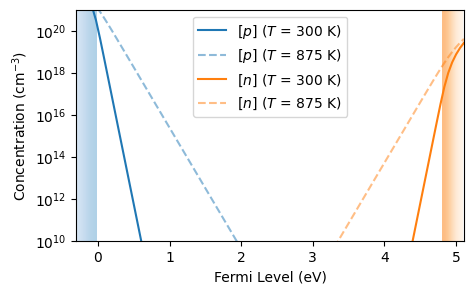

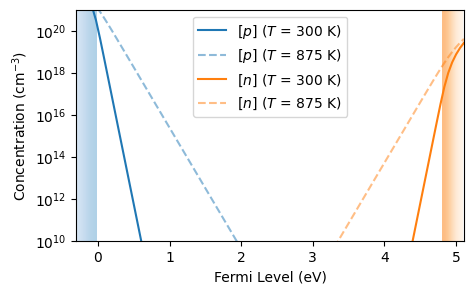

In [11]:
import numpy as np
import matplotlib.pyplot as plt

f,ax = plt.subplots(figsize=(5,3))
band_gap = MgO_thermo_QE.band_gap
anneal_T = 875
e_concs = []; h_concs = []; fermi_levels = np.linspace(-0.3, band_gap + 0.3, 100)
high_temp_e_concs = []; high_temp_h_concs = []
for fermi_level in fermi_levels:
    e_conc, h_conc = MgO_thermo_QE.bulk_dos.get_e_h_concs( fermi_level=MgO_thermo_QE.vbm + fermi_level, temperature=300)
    e_concs.append(e_conc); h_concs.append(h_conc)
    e_conc, h_conc = MgO_thermo_QE.bulk_dos.get_e_h_concs(
       fermi_level=MgO_thermo_QE.vbm + fermi_level, temperature=anneal_T)
    high_temp_e_concs.append(e_conc); high_temp_h_concs.append(h_conc)

ax.plot(fermi_levels, h_concs, label="$[p]$ ($T$ = 300 K)", color="C0")
ax.plot(fermi_levels, high_temp_h_concs, label=f"$[p]$ ($T$ = {anneal_T} K)", color="C0", ls="--", alpha=0.5)
ax.plot(fermi_levels, e_concs, label="$[n]$ ($T$ = 300 K)", color="C1")
ax.plot(fermi_levels, high_temp_e_concs, label=f"$[n]$ ($T$ = {anneal_T} K)", color="C1", ls="--", alpha=0.5)
ax.set_xlabel("Fermi Level (eV)"); ax.set_ylabel("Concentration (cm$^{-3}$)")
ax.legend(); ax.semilogy()

# show VB in blue from -0.3 to 0 eV and CB in orange from CBM to CBM + 0.3 eV:
ax.imshow([(0, 1), (0, 1)], cmap=plt.cm.Blues, extent=(ax.get_xlim()[0], 0, ax.get_ylim()[1], ax.get_ylim()[0]),
          vmin=0, vmax=3, interpolation="bicubic", rasterized=True, aspect="auto")

ax.imshow([(1, 0), (1, 0)], cmap=plt.cm.Oranges, extent=(band_gap, band_gap + 0.3, ax.get_ylim()[0], ax.get_ylim()[1]),
          vmin=0, vmax=3, interpolation="bicubic", rasterized=True, aspect="auto")
ax.set_xlim(-0.3, band_gap + 0.3); ax.set_ylim(1e10, 1e21);  # set axis limits
f

In [12]:
import numpy as np
from tqdm import tqdm

anneal_temperatures = np.arange(200, 1401, 50)  # annealing temperatures to consider, in K
annealing_dict = {}

for anneal_temp in tqdm(anneal_temperatures):
    (fermi_level, e_conc, h_conc, conc_df,
     annealing_fermi_level, annealing_e_conc, annealing_h_conc, _annealing_conc_df
     ) = MgO_thermo_QE.get_fermi_level_and_concentrations(
        bulk_dos=MgO_thermo_QE.bulk_dos, limit="Mg-rich", annealing_temperature=anneal_temp, skip_formatting=True,
        return_annealing_values=True,  # return annealing Fermi level & concentrations for comparison
    )  # quenching to 300K (default) – alternatively can specify quench (operating) temperature
    annealing_dict[anneal_temp] = {
        "annealing_fermi_level": annealing_fermi_level,
        "annealing_e_conc": annealing_e_conc,
        "annealing_h_conc": annealing_h_conc,
        "fermi_level": fermi_level,
        "e_conc": e_conc,
        "h_conc": h_conc,
        "conc_df": conc_df
    }

100%|██████████| 25/25 [00:01<00:00, 24.51it/s]


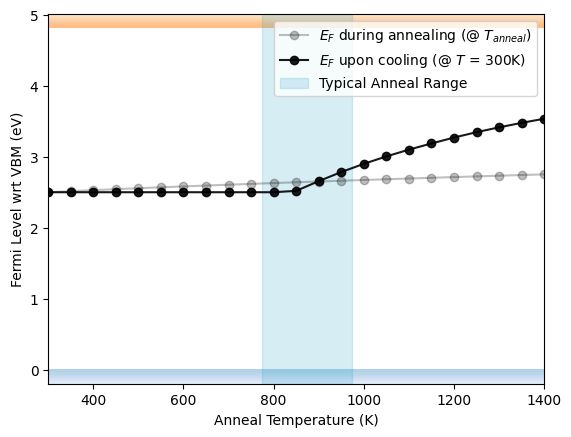

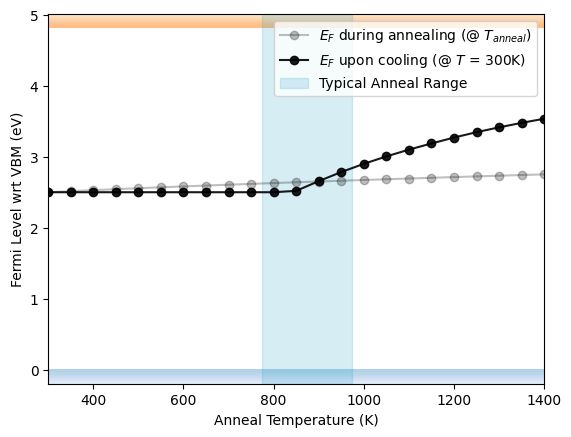

In [13]:
import matplotlib.pyplot as plt
f,ax = plt.subplots()

anneal_fermi_levels = np.array([v["annealing_fermi_level"] for k, v in annealing_dict.items()])
quenched_fermi_levels = np.array([v["fermi_level"] for k, v in annealing_dict.items()])
ax.plot(anneal_temperatures, anneal_fermi_levels, marker='o',
        label="$E_F$ during annealing (@ $T_{anneal}$)", color = "k", alpha=0.25)
ax.plot(anneal_temperatures, quenched_fermi_levels, marker='o',
        label="$E_F$ upon cooling (@ $T$ = 300K)", color = "k", alpha=0.9)
ax.set_xlabel('Anneal Temperature (K)')
ax.set_ylabel('Fermi Level wrt VBM (eV)')
ax.set_xlim(300, 1400)
ax.axvspan(500+273.15, 700+273.15, alpha=0.2, color='#33A7CC', label="Typical Anneal Range")
ax.legend()

# show VB in blue and CB in orange:
ax.imshow([(1, 1), (0, 0)], cmap=plt.cm.Blues, extent=(ax.get_xlim()[0], ax.get_xlim()[1], -0.3, 0),
          vmin=0, vmax=3, interpolation="bicubic", rasterized=True, aspect="auto")
ax.imshow([(0, 0,), (1, 1)], cmap=plt.cm.Oranges, extent=(ax.get_xlim()[0], ax.get_xlim()[1], band_gap, band_gap+0.3),
          vmin=0, vmax=3, interpolation="bicubic", rasterized=True, aspect="auto",)
ax.set_ylim(-0.2, band_gap+0.2)
f

In [14]:
fermi_level, e_conc, h_conc, conc_df = MgO_thermo_QE.get_fermi_level_and_concentrations(
    limit="Mg-rich", annealing_temperature=1400  # annealing temperature in Kelvin
)
print(f"Self-consistent Fermi level for MgO under Mg-rich conditions, annealed at 1400 K, quenched to 300 K (and using the un-physical example case of only Mg_O defects): {fermi_level:.2f} eV relative to VBM")
print(f"Electron concentration: {e_conc:.2e} cm^-3")
print(f"Hole concentration: {h_conc:.2e} cm^-3")

Self-consistent Fermi level for MgO under Mg-rich conditions, annealed at 1400 K, quenched to 300 K (and using the un-physical example case of only Mg_O defects): 3.54 eV relative to VBM
Electron concentration: 3.69e-05 cm^-3
Hole concentration: 5.69e-40 cm^-3


In [15]:
from doped.thermodynamics import FermiSolver

fs = FermiSolver(MgO_thermo_QE)
conc_df = fs.scan_temperature(
    limit="Mg-rich",
    annealing_temperature_range = range(300, 1310, 50)  # temperatures to scan over, in K,
)
conc_df

100%|██████████| 21/21 [00:00<00:00, 23.15it/s]


Concentration (cm^-3)  Formation Energy (eV)  \
Defect Charge                                                 
Mg_O   4               5.399193e-128                 11.281   
       3               5.573781e-128                  9.000   
       2               1.823643e-101                  7.404   
       1               5.399193e-128                  9.188   
       4               1.176537e-110                 11.281   
...                              ...                    ...   
       1                2.415914e-09                 10.034   
       4                3.350735e-08                 14.940   
       3                3.350735e-08                 11.744   
       2                3.350735e-08                  9.233   
       1                3.350735e-08                 10.102   

              Charge State Population  Total Concentration (cm^-3)  \
Defect Charge                                                        
Mg_O   4                        0.00%                1.823643e-101   
       3                        0.00%                1.823643e-101   
       2                      100.00%                1.823643e-101   
       1                        0.00%                1.823643e-101   
       4                        0.00%                 3.973898e-84   
...                               ...                          ...   
       1                       25.00%                 9.663657e-09   
       4                       25.00%                 1.340294e-07   
       3                       25.00%                 1.340294e-07   
       2                       25.00%                 1.340294e-07   
       1                       25.00%                 1.340294e-07   

               Annealing Temperature (K)  Quenched Temperature (K)  \
Defect Charge                                                        
Mg_O   4                             300                       300   
       3                             300                       300   
       2                             300                       300   
       1                             300                       300   
       4                             350                       300   
...                                  ...                       ...   
       1                            1250                       300   
       4                            1300                       300   
       3                            1300                       300   
       2                            1300                       300   
       1                            1300                       300   

               Fermi Level (eV wrt VBM)  Electrons (cm^-3)  Holes (cm^-3)  \
Defect Charge                                                               
Mg_O   4                       2.499283       1.448678e-22   1.448678e-22   
       3                       2.499283       1.448678e-22   1.448678e-22   
       2                       2.499283       1.448678e-22   1.448678e-22   
       1                       2.499283       1.448678e-22   1.448678e-22   
       4                       2.499283       1.448678e-22   1.448678e-22   
...                                 ...                ...            ...   
       1                       3.345875       2.415914e-08   8.686847e-37   
       4                       3.413857       3.350735e-07   6.263306e-38   
       3                       3.413857       3.350735e-07   6.263306e-38   
       2                       3.413857       3.350735e-07   6.263306e-38   
       1                       3.413857       3.350735e-07   6.263306e-38   

               μ_Mg (eV)  μ_O (eV)  
Defect Charge                       
Mg_O   4             0.0  -5.38616  
       3             0.0  -5.38616  
       2             0.0  -5.38616  
       1             0.0  -5.38616  
       4             0.0  -5.38616  
...                  ...       ...  
       1             0.0  -5.38616  
       4             0.0  -5.38616  
 

We can calculate the carrier concentrations for every charged defect with the following method as done in the GGA_workflow_tutorial.ipynb

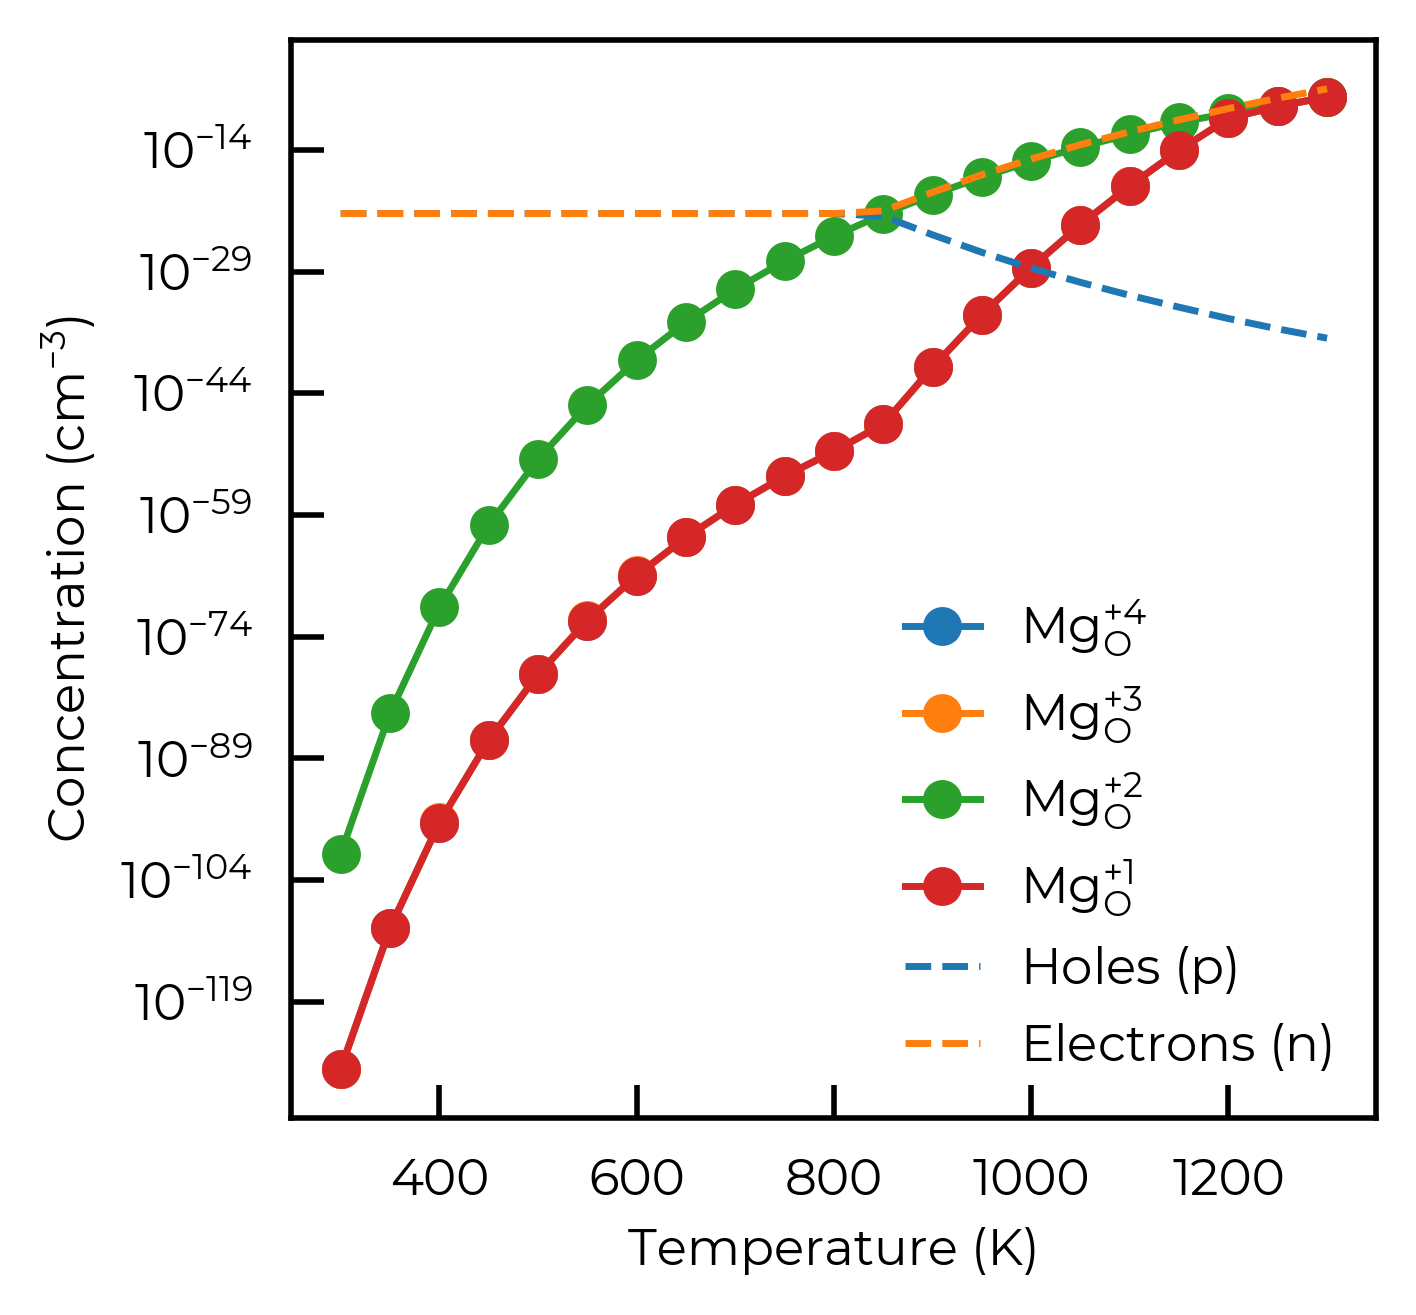

In [16]:
import matplotlib.pyplot as plt
import doped
from doped.utils.plotting import format_defect_name

plt.style.use(f"{doped.__path__[0]}/utils/doped.mplstyle")  # consistent doped plot style

fig, ax = plt.subplots()
for defect in conc_df.index.unique():  # plot the defect concentration(s)
    defect_df = conc_df.loc[[defect]]
    defect_name = f"{defect[0]}_{defect[1]}"
    ax.plot(defect_df["Annealing Temperature (K)"], defect_df["Concentration (cm^-3)"],
            marker="o", label=format_defect_name(defect_name))

# the carrier concentrations are the same for every defect row at a given
# temperature, so we just take one row per temperature:
carrier_df = conc_df.drop_duplicates("Annealing Temperature (K)")
ax.plot(carrier_df["Annealing Temperature (K)"], carrier_df["Holes (cm^-3)"],
        linestyle="--", color="C0", label="Holes ($p$)")
ax.plot(carrier_df["Annealing Temperature (K)"], carrier_df["Electrons (cm^-3)"],
        linestyle="--", color="C1", label="Electrons ($n$)")

ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Concentration (cm$^{-3}$)")
ax.set_yscale("log")
ax.legend(frameon=False)
plt.show()

## Carrier concentrations with a another bulk DOS: VASP DOS vs QE DOS

The VASP bulk DOS used in `GGA_workflow_tutorial.ipynb` was computed with Gaussian smearing (`ISMEAR = 0`), which softens the band edges and narrows the band gap. Below we compare two ways of supplying a corrected bulk DOS to the **same VASP defect energetics** (`MgO_thermo_VASP`), so the only thing that changes is the DOS:

1. **VASP DOS, gap-scissored** — take the smeared VASP DOS and raise its conduction band (`delta_CBM`) so the gap matches the QE gap.
2. **QE DOS, rigidly shifted** — take the (sharp, tetrahedron-method) QE DOS and rigidly shift it (equal `delta_VBM` and `delta_CBM`) so its VBM lands on the VASP VBM.


In [17]:
from monty.serialization import loadfn


MgO_thermo_VASP = loadfn("./MgO/MgO_thermo.json.gz")
MgO_thermo_VASP.bulk_dos = "MgO/MgO_DOS_vasprun.xml.gz"
vasp_raw_dos = MgO_thermo_VASP.bulk_dos

In [18]:

MgO_thermo_VASP.bulk_dos.get_gap() - MgO_thermo_QE.bulk_dos.get_gap()

np.float64(-0.859427256520096)

In [19]:

vasp_to_qe_gap_shift = MgO_thermo_QE.bulk_dos.get_gap() - vasp_raw_dos.get_gap()
shifted_vasp_dos = scissor_dos(vasp_raw_dos, delta_CBM=vasp_to_qe_gap_shift)

Orig gap: 3.9272, new gap:4.7866


thermodynamics.py:5175: UserWarning: The new band gap does not appear to be equal to the original band gap plus the scissor shift, suggesting an error in `scissor_dos`, beware!
Got original gap (from manual indexing): 4.207800000000001, 3.9272044863605147 from dos.get_gap(tol=tol) and new gap: 4.78663174288061


In [22]:
import pandas as pd

runs = {
    "VASP DOS (gap scissored to espresso gap)": MgO_thermo_VASP,
    "espresso DOS (rigidly shifted to VASP VBM)": MgO_thermo_VASP_with_QE_DOS,
}
comparison = {}
for label, thermo in runs.items():
    fermi_level, e_conc, h_conc, _conc_df = thermo.get_fermi_level_and_concentrations(
        limit="Mg-rich", annealing_temperature=1400,  # anneal at 1400 K, quench to 300 K
    )
    comparison[label] = {
        "E_F (eV wrt VBM)": f"{fermi_level:.3f}",
        "n (cm^-3)": f"{e_conc:.3e}",
        "p (cm^-3)": f"{h_conc:.3e}",
    }

comparison_df = pd.DataFrame(comparison).T
print("Self-consistent Fermi level & carrier concentrations (Mg-rich, anneal 1400 K -> quench 300 K):")
comparison_df

Self-consistent Fermi level & carrier concentrations (Mg-rich, anneal 1400 K -> quench 300 K):


,E_F (eV wrt VBM),n (cm^-3),p (cm^-3)
VASP DOS (gap scissored to QE gap),4.053,4.090e-05,1.491e-44
QE DOS (rigidly shifted to VASP VBM),4.053,4.090e-05,1.491e-44


### Testing the fixed `scissor_dos` rigid shift (single call)

`scissor_dos` previously crashed with a `KeyError` whenever the requested gap change snapped to zero grid points (`values_to_remove_or_add == 0`) — in particular for a **pure rigid shift** (`delta_VBM == delta_CBM`, i.e. `delta_gap = 0`), which is exactly what the QE → VASP energy-reference realignment needs. That's why the cell above used a two-step workaround (shift the VBM, then the CBM, in separate calls, each with a large intermediate gap change).

With the fix, the rigid shift works in a **single call**. Below we test it by applying `qe_to_vasp_shift` directly and checking that: the gap is exactly preserved, the band edges (and `efermi`) shift by exactly `qe_to_vasp_shift`, the result matches the two-step `shifted_qe_dos_final`, and the carrier concentrations with the VASP defect energetics are identical to the "QE DOS (rigidly shifted to VASP VBM)" row above.

In [23]:
import numpy as np

# single-call rigid shift (previously raised KeyError; delta_gap = 0 here):
single_shifted_qe_dos = scissor_dos(
    MgO_dos, delta_VBM=qe_to_vasp_shift, delta_CBM=qe_to_vasp_shift
)

orig_cbm, orig_vbm = MgO_dos.get_cbm_vbm()
new_cbm, new_vbm = single_shifted_qe_dos.get_cbm_vbm()
print(f"espresso DOS edges:   VBM {orig_vbm:.4f} -> {new_vbm:.4f}  (shift = {new_vbm - orig_vbm:+.4f}, "
      f"target {qe_to_vasp_shift:+.4f})")
print(f"                CBM {orig_cbm:.4f} -> {new_cbm:.4f}  (shift = {new_cbm - orig_cbm:+.4f})")
print(f"gap preserved:  {orig_cbm - orig_vbm:.4f} -> {new_cbm - new_vbm:.4f}")
print(f"efermi carried: {MgO_dos.efermi:.4f} -> {single_shifted_qe_dos.efermi:.4f}; "
      f"nelecs = {single_shifted_qe_dos.nelecs}")

# matches the two-step workaround exactly:
assert np.allclose(single_shifted_qe_dos.get_cbm_vbm(), shifted_qe_dos_final.get_cbm_vbm(), atol=1e-6)
print("\nsingle-call result matches the two-step `shifted_qe_dos_final` edges ✓")

# apply it: same VASP defect energetics with the single-call-shifted espresso DOS
MgO_thermo_VASP_single_shift = deepcopy(MgO_thermo_VASP)
MgO_thermo_VASP_single_shift.bulk_dos = single_shifted_qe_dos
fermi_level, e_conc, h_conc, _conc_df = MgO_thermo_VASP_single_shift.get_fermi_level_and_concentrations(
    limit="Mg-rich", annealing_temperature=1400
)
print(f"\nMg-rich, anneal 1400 K -> quench 300 K (single-call shifted espresso DOS):")
print(f"E_F = {fermi_level:.3f} eV wrt VBM, n = {e_conc:.3e} cm^-3, p = {h_conc:.3e} cm^-3")
# same as the "espresso DOS (rigidly shifted to VASP VBM)" row in the comparison table above

NameError: name 'qe_to_vasp_shift' is not defined